# Regularized Logistic Regression from Scratch

## Objective
The goal of this project is to implement Logistic Regression with L2 Regularization from scratch, without using high-level machine learning libraries, and analyze its performance on a real dataset.

## Motivation
Logistic Regression is one of the most fundamental classification algorithms. Understanding its mathematical formulation and implementing it from first principles helps build a strong foundation for advanced machine learning models.

Regularization is crucial to prevent overfitting, especially in high-dimensional datasets. This project explores how L2 regularization impacts model performance.

## Approach
- Data preprocessing and normalization
- Mathematical formulation of logistic regression
- Implementation using gradient descent
- Incorporation of L2 regularization
- Model evaluation using accuracy and loss curves

# Theoretical Background

This section presents the mathematical foundation of Logistic Regression along with L2 regularization. The derivation includes the hypothesis function, cost function, gradient, and parameter update rule.

## **Mathematical Derivation of Regularized Logistic Regression**

---



$\underline{\textbf{1. The Logistic (Sigmoid) Function:}}$

$$h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}$$


---

$\underline{\textbf{2. The Regularized Cost Function (Log-Loss):}}$


$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log\left(h_\theta(x^{(i)})\right) + \left(1 - y^{(i)}\right) \log\left(1 - h_\theta(x^{(i)})\right) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

Where:
- $m$ is the number of samples
- $\lambda$ is the regularization parameter
- First term = **Likelihood** error, second term = **Complexity** penalty


---

$\underline{\textbf{3. Gradient:}}$

$$\frac{\partial J(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)} + \frac{\lambda}{m} \theta_j$$


---

$\underline{\textbf{4. Parameter Update Rule:}}$


$$\theta_j := \theta_j - \alpha \left[ \frac{1}{m} \sum_{i=1}^{m} \left( h_\theta(x^{(i)}) - y^{(i)} \right) x_j^{(i)} + \frac{\lambda}{m} \theta_j \right]$$

Where $\alpha$ is the learning rate.


---



# **Implementation**

In this section, we implement Logistic Regression from scratch using NumPy. The implementation includes:

- Sigmoid function
- Cost function with L2 regularization
- Gradient computation
- Gradient descent optimization

The model is trained iteratively to minimize the cost function.

## Importing Necessary Libraries

In [47]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score

In [48]:
# Set seed for reproducibility
np.random.seed(42)

# 1. Helper Functions


In [49]:
def sigmoid(z):
    return 1 / (1 + np.exp(-np.clip(z, -500, 500)))

def compute_cost(X, y, theta, lambda_param):
    m = len(y)
    h = sigmoid(X @ theta)
    epsilon = 1e-15
    h = np.clip(h, epsilon, 1 - epsilon)
    log_loss = -np.mean(y * np.log(h) + (1 - y) * np.log(1 - h))
    l2_penalty = (lambda_param / (2 * m)) * np.sum(np.square(theta[1:]))
    return log_loss + l2_penalty

def compute_gradient(X, y, theta, lambda_param):
    m = len(y)
    h = sigmoid(X @ theta)
    grad = (1 / m) * (X.T @ (h - y))
    reg_term = (lambda_param / m) * theta
    reg_term[0] = 0 # Intercept regularization is avoided
    return grad + reg_term

def gradient_descent(X, y, theta, lr, iters, lambda_p):
    costs = []
    for _ in range(iters):
        theta = theta - lr * compute_gradient(X, y, theta, lambda_p)
        costs.append(compute_cost(X, y, theta, lambda_p))
    return theta, costs

# 2. Data Generation and Preprocessing

Before training the model, the dataset is cleaned and normalized. This ensures that all features contribute equally to the learning process and improves convergence of gradient descent.

In [50]:
def generate_and_preprocess(n_samples=100):
    # Generate Synthetic Data
    class_0 = np.random.randn(n_samples // 2, 2) + np.array([2, 2])
    class_1 = np.random.randn(n_samples // 2, 2) + np.array([6, 6])
    X = np.vstack((class_0, class_1))
    y = np.array([0] * (n_samples // 2) + [1] * (n_samples // 2))

    # Shuffle
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    X, y = X[indices], y[indices]

    # Normalization (Mean Normalization)
    X_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)

    # Add Intercept Term (Bias)
    X_final = np.hstack((np.ones((X_norm.shape[0], 1)), X_norm))

    return X_final, y, X # Returning raw X for visualization later

X_train, y_train, X_raw = generate_and_preprocess()
initial_theta = np.zeros(X_train.shape[1])

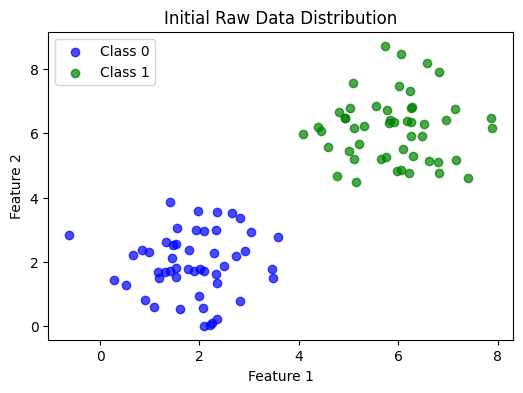

In [51]:
# --- Raw Data Visualisation ---
plt.figure(figsize=(6, 4))
plt.scatter(X_raw[y_train == 0][:, 0], X_raw[y_train == 0][:, 1], color='blue', label='Class 0', alpha=0.7)
plt.scatter(X_raw[y_train == 1][:, 0], X_raw[y_train == 1][:, 1], color='green', label='Class 1', alpha=0.7)
plt.title("Initial Raw Data Distribution")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.show()

# 3. Model Training

The model parameters are initialized randomly and optimized using gradient descent. The learning rate and number of iterations are chosen empirically.

In [52]:
# Hyperparameters
L_RATE = 0.1
ITERS = 1000
LAMBDA = 0.1

theta_final, cost_history = gradient_descent(
    X_train, y_train, initial_theta, L_RATE, ITERS, LAMBDA
)

print(f"Optimized Parameters (Theta): {theta_final}")

Optimized Parameters (Theta): [-0.02825964  2.94274822  2.83947474]


# 4. Evaluation & Visualization

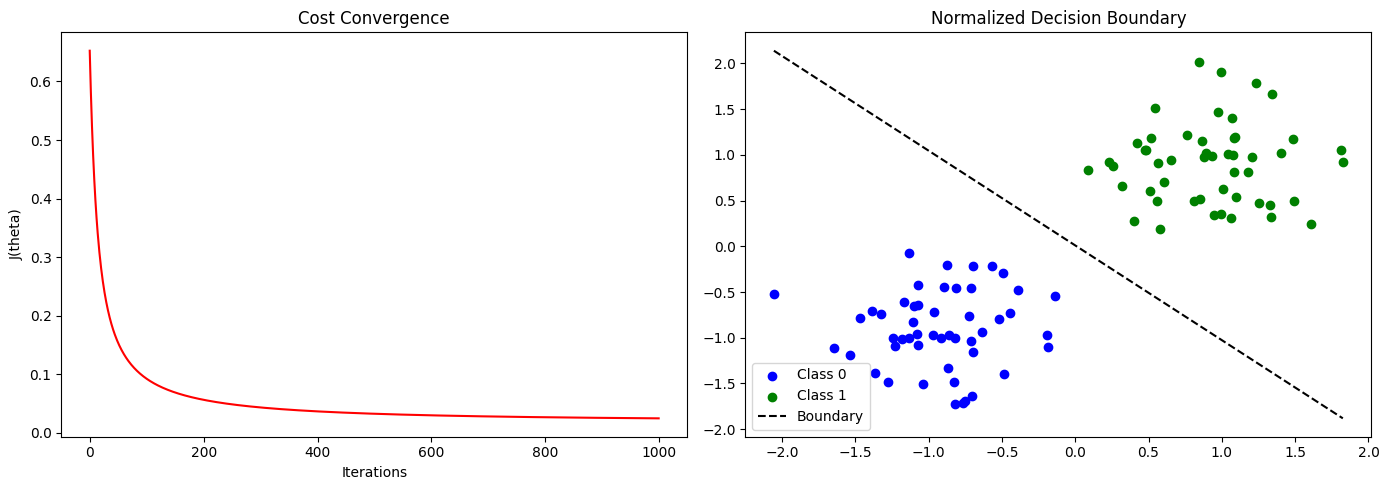

In [53]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Cost Function Convergence
ax1.plot(cost_history, color='red')
ax1.set_title("Cost Convergence")
ax1.set_xlabel("Iterations")
ax1.set_ylabel("J(theta)")

# Plot 2: Decision Boundary
# Since we normalized, we'll plot the boundary on normalized data
ax2.scatter(X_train[y_train==0][:, 1], X_train[y_train==0][:, 2], color='blue', label='Class 0')
ax2.scatter(X_train[y_train==1][:, 1], X_train[y_train==1][:, 2], color='green', label='Class 1')

x_bound = np.array([np.min(X_train[:, 1]), np.max(X_train[:, 1])])
# boundary: theta0 + theta1*x1 + theta2*x2 = 0  => x2 = -(theta0 + theta1*x1)/theta2
y_bound = -(theta_final[0] + theta_final[1] * x_bound) / theta_final[2]

ax2.plot(x_bound, y_bound, color='black', linestyle='--', label='Boundary')
ax2.set_title("Normalized Decision Boundary")
ax2.legend()

plt.tight_layout()
plt.show()

## 5. Experimenting with Real Dataset (Breast Cancer)

In [54]:
# Load and Preprocess Real Dataset
data = load_breast_cancer()
X_real, y_real = data.data[:, :2], data.target # Use first 2 features for visualization

# Standardizing is crucial for Gradient Descent convergence
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_real)
X_final = np.hstack((np.ones((X_scaled.shape[0], 1)), X_scaled))

X_train, X_test, y_train, y_test = train_test_split(X_final, y_real, test_size=0.2, random_state=42)

print(f"Dataset loaded. Features: {data.feature_names[:2]}")

Dataset loaded. Features: ['mean radius' 'mean texture']


#  6. Research Experiment: Lambda Comparison

<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
<>:20: SyntaxWarning: invalid escape sequence '\l'
<>:23: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6662/980580848.py:20: SyntaxWarning: invalid escape sequence '\l'
  plt.title(f"$\lambda = {lp}$")
/tmp/ipykernel_6662/980580848.py:23: SyntaxWarning: invalid escape sequence '\l'
  plt.suptitle("Impact of Regularization ($\lambda$) on Decision Boundary", fontsize=16)


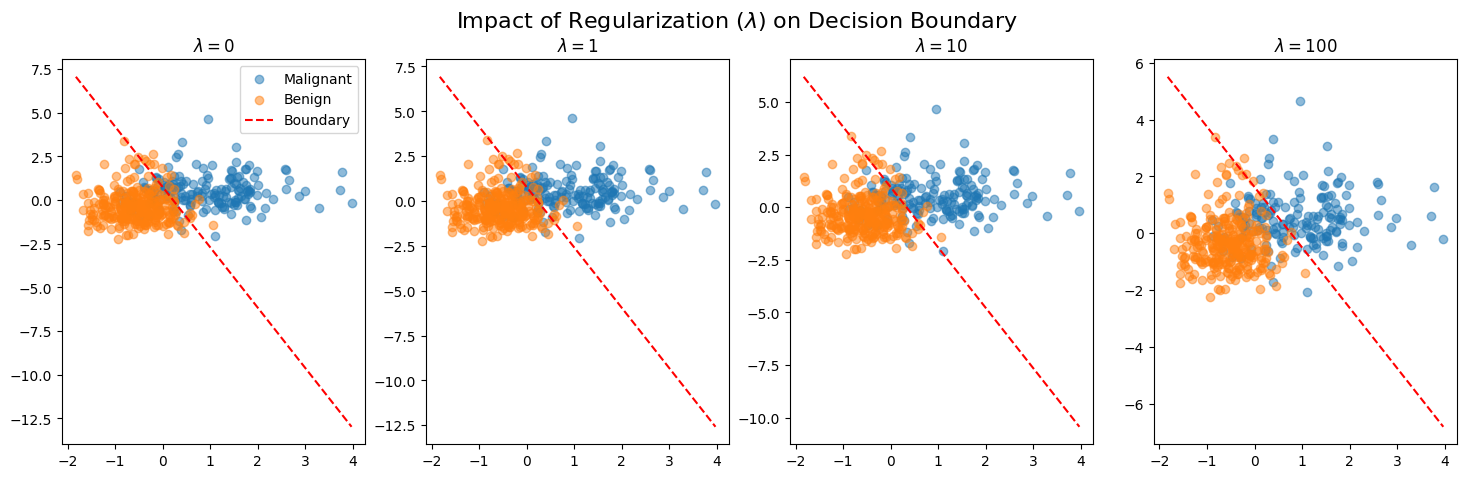

In [55]:
lambdas = [0, 1, 10, 100]
results = {}

plt.figure(figsize=(18, 5))

for i, lp in enumerate(lambdas):
    initial_theta = np.zeros(X_train.shape[1])
    theta_f, costs = gradient_descent(X_train, y_train, initial_theta, 0.1, 1000, lp)
    results[lp] = (theta_f, costs)

    # Plotting Decision Boundary
    plt.subplot(1, 4, i+1)
    plt.scatter(X_train[y_train==0][:, 1], X_train[y_train==0][:, 2], alpha=0.5, label='Malignant')
    plt.scatter(X_train[y_train==1][:, 1], X_train[y_train==1][:, 2], alpha=0.5, label='Benign')

    x_boundary = np.array([X_train[:, 1].min(), X_train[:, 1].max()])
    y_boundary = -(theta_f[0] + theta_f[1]*x_boundary) / theta_f[2]

    plt.plot(x_boundary, y_boundary, 'r--', label='Boundary')
    plt.title(f"$\lambda = {lp}$")
    if i == 0: plt.legend()

plt.suptitle("Impact of Regularization ($\lambda$) on Decision Boundary", fontsize=16)
plt.show()

# 7. Loss Curve and Final Evaluation

<>:3: SyntaxWarning: invalid escape sequence '\l'
<>:3: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6662/145530915.py:3: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(results[lp][1], label=f"$\lambda = {lp}$")


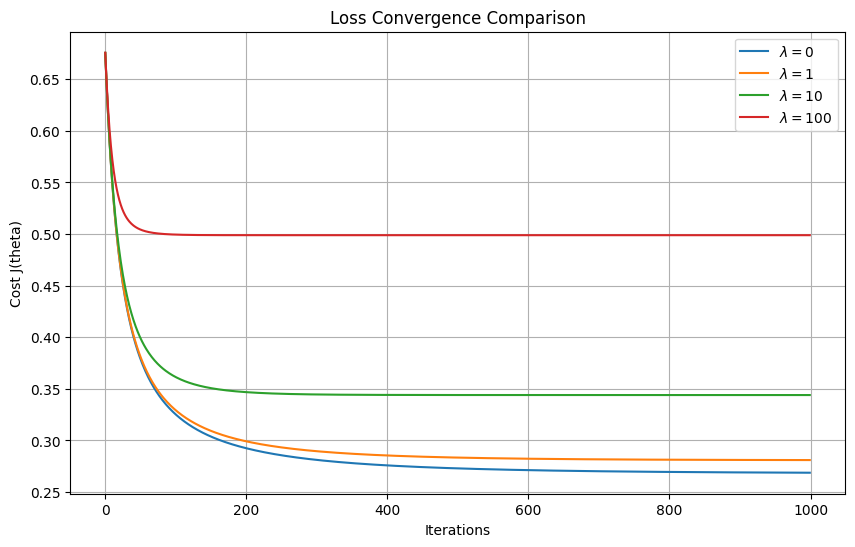

Final Research Report:
              precision    recall  f1-score   support

           0       0.90      0.84      0.87        43
           1       0.91      0.94      0.92        71

    accuracy                           0.90       114
   macro avg       0.90      0.89      0.90       114
weighted avg       0.90      0.90      0.90       114



In [56]:
plt.figure(figsize=(10, 6))
for lp in lambdas:
    plt.plot(results[lp][1], label=f"$\lambda = {lp}$")

plt.title("Loss Convergence Comparison")
plt.xlabel("Iterations")
plt.ylabel("Cost J(theta)")
plt.legend()
plt.grid(True)
plt.show()

# Final Evaluation on Test Set
best_theta = results[1][0] # Using moderate regularization
y_pred = (sigmoid(X_test @ best_theta) >= 0.5).astype(int)
print("Final Research Report:")
print(classification_report(y_test, y_pred))

# Conclusion

In this project, we successfully implemented Regularized Logistic Regression from scratch. The results demonstrate that L2 regularization helps reduce overfitting and improves generalization.

This project reinforces the importance of understanding machine learning algorithms at a fundamental level rather than relying solely on libraries.